In [48]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns
import matplotlib.pyplot as plt

import joblib
import os

In [51]:
#Load Cleaned Data
df = pd.read_csv(r'C:\Users\MANGESH\customer churn prediction\data\feature_engineered_telco.csv')
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,TenureGroup,ChargeCategory
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,14.925000,0-12,Low
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,0,53.985714,25-48,Medium
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,36.050000,0-12,Medium
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,40.016304,25-48,Low
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,50.550000,0-12,Medium


In [50]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [54]:
categorical_cols = X.select_dtypes(
    include="object"
).columns.tolist()

categorical_cols += X.select_dtypes(
    include="category"
).columns.tolist()

numeric_cols = X.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

print(categorical_cols)

print(numeric_cols)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup', 'ChargeCategory']
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend']


In [55]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_cols
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_cols
        )
    ]
)

In [56]:
pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42
            )
        )
    ]
)

In [57]:
pipeline.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [58]:
y_pred = pipeline.predict(
    X_test
)

In [59]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    round(accuracy,4)
)

Accuracy: 0.7779


In [60]:
precision = precision_score(
    y_test,
    y_pred
)

print(
    "Precision:",
    round(precision,4)
)

Precision: 0.6007


In [61]:
recall = recall_score(
    y_test,
    y_pred
)

print(
    "Recall:",
    round(recall,4)
)

Recall: 0.4866


In [62]:
f1 = f1_score(
    y_test,
    y_pred
)

print(
    "F1 Score:",
    round(f1,4)
)

F1 Score: 0.5377


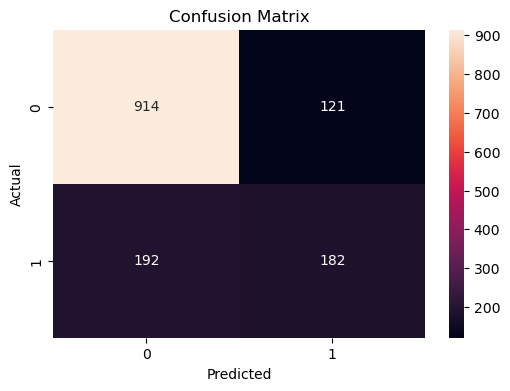

In [63]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(
    figsize=(6,4)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

In [64]:
rf = pipeline.named_steps[
    "classifier"
]

importances = rf.feature_importances_

print(
    "Number of Features Learned:",
    len(importances)
)

Number of Features Learned: 54


In [65]:
os.makedirs(
    "../models",
    exist_ok=True
)

In [66]:
joblib.dump(
    pipeline,
    "../models/churn_pipeline.pkl"
)

print(
    "Pipeline Saved Successfully"
)

Pipeline Saved Successfully


In [67]:
loaded_pipeline = joblib.load(
    "../models/churn_pipeline.pkl"
)

sample = X_test.iloc[:5]

preds = loaded_pipeline.predict(
    sample
)

print(preds)

[0 1 0 0 0]
